TIỀN XỬ LÝ DỮ LIỆU

In [57]:
import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import StratifiedKFold

In [58]:
# === CẤU HÌNH THƯ MỤC ===
RAW_DATA_DIR   = r'D:/Do_An/Data_Raw'    
DATA_DIR       = r'D:/Do_An/Data'        
BLACKLIST_FILE = 'blacklist.txt'         
FINAL_DATA_DIR = r'D:/Do_An/Data_Final'  

# === CẤU HÌNH ẢNH ===
IMG_SIZE       = (224, 224)
ZOOM_FACTOR    = 2.0
BATCH_SIZE     = 32
SEED           = 123

In [86]:
# 1. Loại bỏ ảnh rò rỉ
blacklist = set()
if os.path.exists(BLACKLIST_FILE):
    with open(BLACKLIST_FILE, 'r', encoding='utf-8') as f:
        for line in f:
            path = line.strip()
            if path:
                # Chuẩn hoá dấu gạch chéo để so sánh
                blacklist.add(os.path.normpath(path))
    print(f"Đã đọc blacklist: {len(blacklist)} đường dẫn bị loại.")
else:
    print("Không tìm thấy blacklist.txt → sẽ copy TẤT CẢ ảnh từ Data_Raw.")

os.makedirs(DATA_DIR, exist_ok=True)

# Duyệt qua Data_Raw 
VALID_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')

count_copied  = 0
count_skipped = 0

all_files = []
for root, dirs, files in os.walk(RAW_DATA_DIR):
    for file in files:
        if file.lower().endswith(VALID_EXTS):
            all_files.append(os.path.join(root, file))

for src_path in tqdm(all_files, desc="Lọc & Copy"):
    norm_src = os.path.normpath(src_path)
    if norm_src in blacklist:
        count_skipped += 1
        continue

    # Tính đường dẫn đích giữ nguyên cấu trúc con
    rel_path = os.path.relpath(src_path, RAW_DATA_DIR)
    dst_path = os.path.join(DATA_DIR, rel_path)
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)

    shutil.copy2(src_path, dst_path)
    count_copied += 1

print(f"\nĐã copy {count_copied} ảnh sạch vào '{DATA_DIR}'.")
print(f" Bỏ qua  {count_skipped} ảnh trùng lặp / rò rỉ.")

# Đổi tên blacklist để đánh dấu đã xử lý
if os.path.exists(BLACKLIST_FILE):
    done_file = BLACKLIST_FILE.replace('.txt', '_DONE.txt')
    os.rename(BLACKLIST_FILE, done_file)
    print(f"   Đã đổi tên '{BLACKLIST_FILE}' → '{done_file}'.")

Đã đọc blacklist: 459 đường dẫn bị loại.


Lọc & Copy: 100%|██████████| 3268/3268 [00:14<00:00, 232.50it/s] 


Đã copy 2810 ảnh sạch vào 'D:/Do_An/Data'.
 Bỏ qua  458 ảnh trùng lặp / rò rỉ.
   Đã đổi tên 'blacklist.txt' → 'blacklist_DONE.txt'.


In [87]:
# Thống kê ảnh 
print(f"{'TẬP':<8} | {'LỚP':<10} | {'SỐ ẢNH':<10}")
print("-" * 35)

total = 0
for split in os.listdir(DATA_DIR):
    split_path = os.path.join(DATA_DIR, split)
    if not os.path.isdir(split_path):
        continue
    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        if not os.path.isdir(label_path):
            continue
        imgs = [f for f in os.listdir(label_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        count = len(imgs)
        total += count
        print(f"{split:<8} | {label:<10} | {count:<10}")

print("-" * 35)
print(f"Tổng cộng: {total} ảnh")

TẬP      | LỚP        | SỐ ẢNH    
-----------------------------------
test     | fresh      | 356       
test     | rotten     | 450       
train    | fresh      | 935       
train    | rotten     | 1069      
-----------------------------------
Tổng cộng: 2810 ảnh


In [90]:
def crop_meat_region(img, out_size=(224, 224), min_area_ratio=0.1):
    if img is None:
        return None, False

    # convert sang RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # chuyển sang HSV để detect màu thịt (đỏ/nâu)
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    # mask vùng màu thịt (điều chỉnh nếu cần)
    lower = np.array([0, 40, 40])
    upper = np.array([25, 255, 255])
    mask1 = cv2.inRange(hsv, lower, upper)

    lower2 = np.array([160, 40, 40])
    upper2 = np.array([180, 255, 255])
    mask2 = cv2.inRange(hsv, lower2, upper2)

    mask = cv2.bitwise_or(mask1, mask2)

    # làm sạch mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # tìm contour
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None, False

    # contour lớn nhất
    c = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(c)

    img_area = img.shape[0] * img.shape[1]

    # ❌ loại ảnh nếu thịt quá nhỏ
    if area / img_area < min_area_ratio:
        return None, False

    # bounding box
    x, y, w, h = cv2.boundingRect(c)

    cropped = img[y:y+h, x:x+w]

    # resize
    resized = cv2.resize(cropped, out_size)

    return resized, True


def resize_dataset_inplace(data_dir, out_size=(224, 224), min_area_ratio=0.1):
    print(f"Đang xử lý ảnh trong: {data_dir}")

    all_imgs = []
    for root, _, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                all_imgs.append(os.path.join(root, file))

    count_ok = 0
    count_removed = 0
    count_err = 0

    with tqdm(total=len(all_imgs), desc="Processing") as pbar:
        for img_path in all_imgs:
            try:
                img = cv2.imread(img_path)

                processed, is_valid = crop_meat_region(
                    img,
                    out_size=out_size,
                    min_area_ratio=min_area_ratio
                )

                if is_valid:
                    cv2.imwrite(img_path, processed)
                    count_ok += 1
                else:
                    # ❌ xóa ảnh nếu không đạt
                    os.remove(img_path)
                    count_removed += 1

            except Exception as e:
                print(f"⚠ Lỗi {img_path}: {e}")
                count_err += 1

            pbar.update(1)

    print("\nHOÀN TẤT!")
    print(f"Ảnh giữ lại : {count_ok}")
    print(f"Ảnh bị loại : {count_removed}")

resize_dataset_inplace(DATA_DIR, out_size=(224, 224), min_area_ratio=0.12)

Đang xử lý ảnh trong: D:/Do_An/Data


Processing: 100%|██████████| 2810/2810 [00:24<00:00, 115.90it/s]


HOÀN TẤT!
Ảnh giữ lại : 2759
Ảnh bị loại : 51


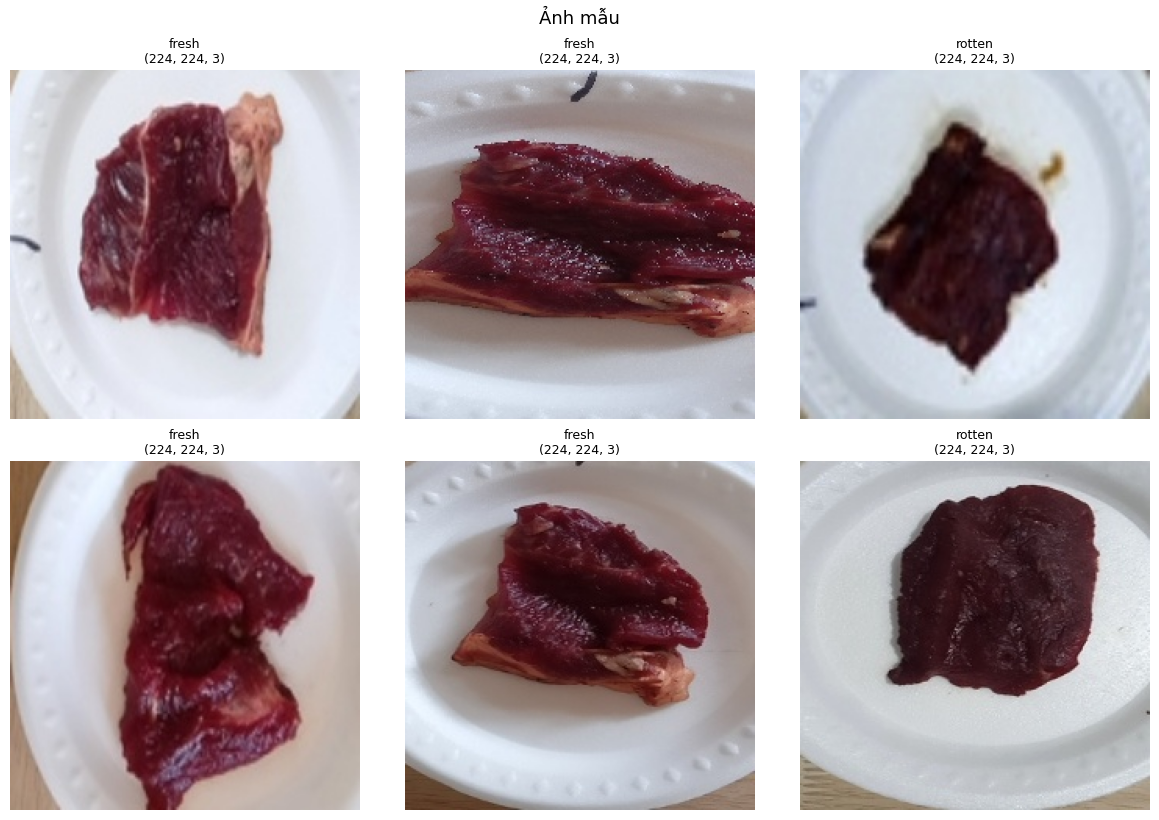

In [89]:
# Hiển thị ảnh ngẫu nhiên từ Data để xác nhận
all_imgs = []
for root, _, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            all_imgs.append(os.path.join(root, f))

random.seed(SEED)
sample = random.sample(all_imgs, min(6, len(all_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, img_path in zip(axes.flat, sample):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    label = os.path.basename(os.path.dirname(img_path))
    ax.imshow(img_rgb)
    ax.set_title(f"{label}\n{img_rgb.shape}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.suptitle("Ảnh mẫu", fontsize=13, y=1.02)
plt.show()

In [91]:
# 3. Chia tập dữ liệu 
K_FOLDS = 5
SEED = 123

# Thu thập tất cả đường dẫn ảnh theo nhãn (gộp hết từ Data)
labels_files = defaultdict(list)
for root, _, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            label = os.path.basename(root)
            labels_files[label].append(os.path.join(root, f))

# Tạo X (đường dẫn) và y (nhãn)
X = []
y = []
for label, file_list in labels_files.items():
    X.extend(file_list)
    y.extend([label] * len(file_list))

X = np.array(X)
y = np.array(y)

print(f"Tổng số ảnh: {len(X)}")
print(f"Fresh : {np.sum(y == 'fresh')}")
print(f"Rotten: {np.sum(y == 'rotten')}")

# Stratified K-Fold để giữ tỷ lệ lớp ở mỗi fold
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

# Tạo thư mục lưu các fold
KFOLD_DIR = os.path.join(FINAL_DATA_DIR, "kfold_splits")
os.makedirs(KFOLD_DIR, exist_ok=True)

fold_info = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    fold_num = fold_idx + 1
    print(f"\nFold {fold_num}/{K_FOLDS}:")
    
    train_files = X[train_idx]
    test_files  = X[test_idx]
    
    # Tách Val từ Train (ví dụ: 15% của train)
    val_size = int(len(train_files) * 0.15)
    np.random.seed(SEED + fold_num)  # khác seed mỗi fold một chút
    val_indices = np.random.choice(len(train_files), val_size, replace=False)
    train_final_indices = np.setdiff1d(np.arange(len(train_files)), val_indices)
    
    train_final = train_files[train_final_indices]
    val_files   = train_files[val_indices]
    
    print(f"  Train : {len(train_final)} ảnh")
    print(f"  Val   : {len(val_files)} ảnh")
    print(f"  Test  : {len(test_files)} ảnh")
    
    # Tạo thư mục cho fold này
    fold_dir = os.path.join(KFOLD_DIR, f"fold_{fold_num}")
    for split in ['train', 'val', 'test']:
        for label in ['fresh', 'rotten']:
            os.makedirs(os.path.join(fold_dir, split, label), exist_ok=True)
    
    # Copy file vào thư mục tương ứng
    def copy_files(file_list, split_name):
        for src in file_list:
            label = os.path.basename(os.path.dirname(src))
            dst = os.path.join(fold_dir, split_name, label, os.path.basename(src))
            shutil.copy2(src, dst)
    
    copy_files(train_final, 'train')
    copy_files(val_files,   'val')
    copy_files(test_files,  'test')
    
    # Lưu thông tin fold
    fold_info.append({
        'fold': fold_num,
        'train_count': len(train_final),
        'val_count': len(val_files),
        'test_count': len(test_files)
    })

print(f"\nCác fold được lưu tại: {KFOLD_DIR}")

Tổng số ảnh: 2759
Fresh : 1291
Rotten: 1468

Fold 1/5:
  Train : 1876 ảnh
  Val   : 331 ảnh
  Test  : 552 ảnh

Fold 2/5:
  Train : 1876 ảnh
  Val   : 331 ảnh
  Test  : 552 ảnh

Fold 3/5:
  Train : 1876 ảnh
  Val   : 331 ảnh
  Test  : 552 ảnh

Fold 4/5:
  Train : 1876 ảnh
  Val   : 331 ảnh
  Test  : 552 ảnh

Fold 5/5:
  Train : 1877 ảnh
  Val   : 331 ảnh
  Test  : 551 ảnh

Các fold được lưu tại: D:/Do_An/Data_Final\kfold_splits
